# Simple Linear Regression

## Objective

In this notebook, we will build a Simple Linear Regression model from scratch.

We will use one feature, `MedInc`, to predict the target variable, `MedHouseVal`.

### Topics
- Understanding the Linear Regression equation
- Finding slope and intercept
- Making predictions
- Calculating the cost function
- Evaluating the model

In [128]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [129]:
from sklearn.datasets import fetch_california_housing

housing = fetch_california_housing(as_frame=True)

df = housing.frame

In [130]:
df.head()

,MedInc,HouseAge,AveRooms,AveBedrms,Population,AveOccup,Latitude,Longitude,MedHouseVal
0,8.3252,41.0,6.984127,1.023810,322.0,2.555556,37.88,-122.23,4.526
1,8.3014,21.0,6.238137,0.971880,2401.0,2.109842,37.86,-122.22,3.585
2,7.2574,52.0,8.288136,1.073446,496.0,2.802260,37.85,-122.24,3.521
3,5.6431,52.0,5.817352,1.073059,558.0,2.547945,37.85,-122.25,3.413
4,3.8462,52.0,6.281853,1.081081,565.0,2.181467,37.85,-122.25,3.422


In [131]:
X = df.iloc[:,0]
y = df.iloc[:,-1]

In [132]:
print(X.shape)
print(y.shape)

(20640,)
(20640,)


In [133]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [134]:
print(X_train.shape)
print(X_test.shape)
print(y_train.shape)
print(y_test.shape)

(16512,)
(4128,)
(16512,)
(4128,)


- x  → MedInc
- ŷ  → predicted MedHouseVal
- m  → how much predicted house value changes when MedInc increases by 1
- b  → predicted house value when MedInc = 0

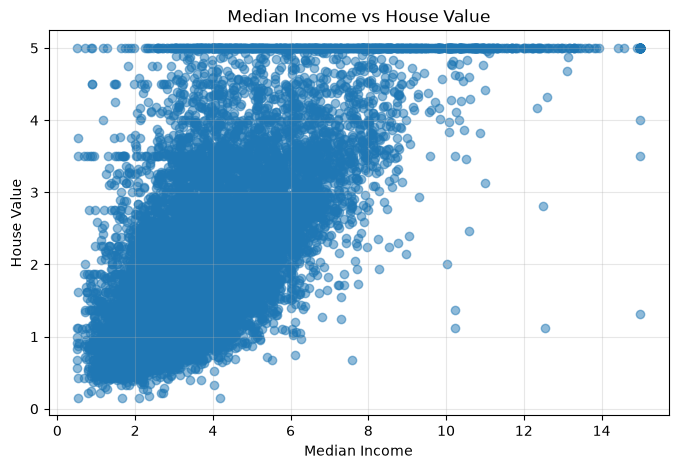

In [135]:
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, alpha=0.5)

plt.title('Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('House Value')

plt.grid(alpha=0.3)
plt.show()

In [136]:
class SLR:
    
    def __init__(self):
        self.m = None
        self.b = None
        
    def fit(self,X_train,y_train):
        
        num = 0
        den = 0
        
        for i in range(X_train.shape[0]):
            num = num + (X_train.iloc[i] - X_train.mean()) * (y_train.iloc[i] - y_train.mean())
            den = den + (X_train.iloc[i] - X_train.mean())**2
            
            self.m = num / den
            self.b = y_train.mean() - (self.m * X_train.mean())
            
        print(self.m,self.b)
        
    def predict(self,X_train):
        return self.m*X_train + self.b
        

In [137]:
lr = SLR()

In [138]:
lr.fit(X_train,y_train)

0.41760514234704 0.45179471231827906


In [139]:
lr.predict(4.12)

np.float64(2.172327898788084)

In [140]:
X_test

6939     3.6875
8032     4.2917
18877    2.4875
4882     1.5652
5409     4.2411
          ...  
6634     6.0700
18858    1.0667
8910     2.5261
9712     3.6875
1118     2.1912
Name: MedInc, Length: 4128, dtype: float64

In [141]:
y_test

6939     1.752
8032     3.147
18877    0.900
4882     1.231
5409     3.509
         ...  
6634     2.618
18858    0.342
8910     3.750
9712     1.897
1118     1.152
Name: MedHouseVal, Length: 4128, dtype: float64

In [142]:
y_pred = lr.predict(X_test)
y_pred

6939     1.991714
8032     2.244031
18877    1.490588
4882     1.105430
5409     2.222900
           ...   
6634     2.986658
18858    0.897254
8910     1.506707
9712     1.991714
1118     1.366851
Name: MedInc, Length: 4128, dtype: float64

In [143]:
mse = np.sum((y_test - y_pred)**2) / y_test.shape[0]
print(f"MSE: {mse}")

MSE: 0.6853089586157505


In [144]:
rmse = np.sqrt(np.sum((y_test - y_pred)**2) / y_test.shape[0])
print(f"RMSE : {rmse}")

RMSE : 0.8278338955465344


The model's predictions are typically off from the actual MedHouseVal values by roughly 0.83 units, in the target's original scale.

0.41760514234704 0.45179471231827906


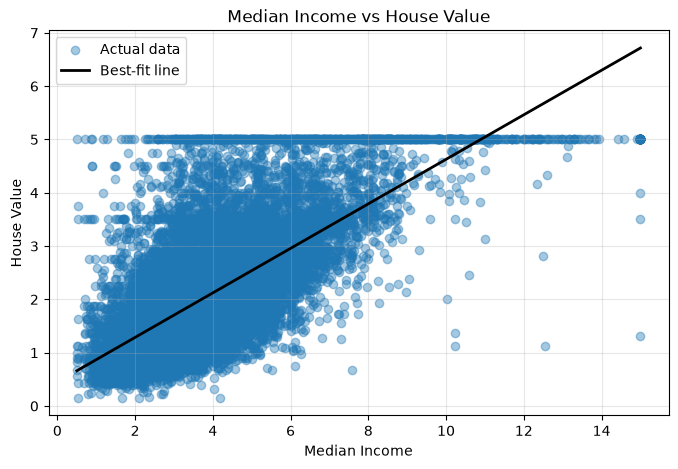

In [145]:
import matplotlib.pyplot as plt
import numpy as np

# Train the model
model = SLR()
model.fit(X_train, y_train)

# Calculate predicted values
y_pred = model.m * X_train + model.b

# Sort X values so the regression line is smooth
sort_idx = np.argsort(X_train)

# Plot
plt.figure(figsize=(8, 5))

plt.scatter(X_train, y_train, alpha=0.4, label='Actual data')
plt.plot(
    X_train.iloc[sort_idx],
    y_pred.iloc[sort_idx],
    linewidth=2,
    label='Best-fit line',
    color='black'
)

plt.title('Median Income vs House Value')
plt.xlabel('Median Income')
plt.ylabel('House Value')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

In [146]:
y_pred = lr.predict(X_test)

In [147]:
num = np.sum((y_test - y_pred)**2)
den = np.sum((y_test - y_test.mean())**2)

r2 = 1 - (num / den)

print(f"R2_Score: {r2}")

R2_Score: 0.4731734586517702


using Simple sklearn 

In [148]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test = train_test_split(X,y,test_size=0.2,random_state=4)

In [149]:
from sklearn.linear_model import LinearRegression
lr = LinearRegression()

In [150]:
lr.fit(X_train.values.reshape(-1, 1), y_train)

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies the convergence criterion of the underlying solver. `tol` isset as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. `tol` is set as `cond` of:func:`scipy.linalg.lstsq` when fitting on dense training data... versionadded:: 1.7.. versionchanged:: 1.9 Now supported on dense data, interpreted as the `cond` parameter.",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary <n_jobs>` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False
Name,Type,Value
"coef_ coef_: array of shape (n_features, ) or (n_targets, n_features)Estimated coefficients for the linear regression problem.If multiple targets are passed during the fit (y 2D), thisis a 2D array of shape (n_targets, n_features), while if onlyone target is passed, this is a 1D array of length n_features.","ndarray[float64](1,)",[0.42]
"intercept_ intercept_: float or array of shape (n_targets,)Independent term in the linear model. Set to 0.0 if`fit_intercept = False`.",float64,0.4518
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`... versionadded:: 0.24,int,1
rank_ rank_: intRank of matrix `X`. Only available when `X` is dense.,int64,np.int64(1)
"singular_ singular_: array of shape (min(X, y),)Singular values of `X`. Only available when `X` is dense.","ndarray[float64](1,)",[245.03]


In [151]:
print(lr.coef_)
print(lr.intercept_)

[0.41760514]
0.4517947123182944


In [152]:
model = SLR()
model.fit(X_train, y_train)

0.41760514234704 0.45179471231827906


In [153]:
print("From Scratch:")
print(model.m)
print(model.b)

print("\nSklearn:")
print(lr.coef_[0])
print(lr.intercept_)

From Scratch:
0.41760514234704
0.45179471231827906

Sklearn:
0.41760514234703605
0.4517947123182944


In [154]:
# From Scratch
model = SLR()
model.fit(X_train, y_train)

y_pred_scratch = model.predict(X_train)

# Sklearn
lr = LinearRegression()
lr.fit(X_train.to_numpy().reshape(-1, 1), y_train)

y_pred_sklearn = lr.predict(X_train.to_numpy().reshape(-1, 1))

# Compare first 5 predictions
print("From Scratch:")
print(y_pred_scratch.head())

print("\nSklearn:")
print(y_pred_sklearn[:5])

0.41760514234704 0.45179471231827906
From Scratch:
4520    0.883306
29      1.156503
7341    1.550096
1067    1.879628
5084    1.038196
Name: MedInc, dtype: float64

Sklearn:
[0.88330611 1.15650339 1.55009624 1.87962845 1.03819585]


In [161]:
y_pred_sklearn = lr.predict(X_test.to_numpy().reshape(-1, 1))

In [162]:
# Predict on TEST data
y_pred_sklearn = lr.predict(X_test.to_numpy().reshape(-1, 1))

# Calculate R²
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred_sklearn)

print("R² Score:", r2)

R² Score: 0.4731734586517701


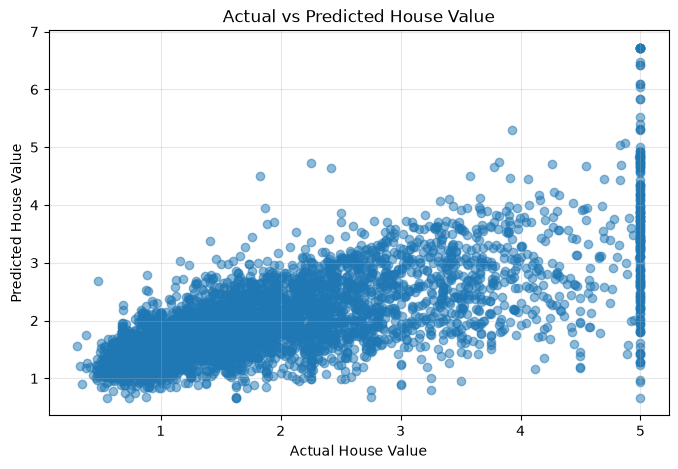

In [163]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_sklearn, alpha=0.5)

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Value')

plt.grid(alpha=0.3)
plt.show()

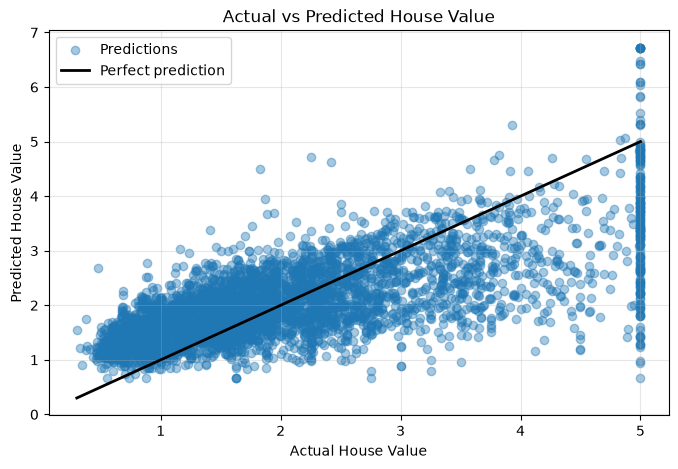

In [164]:
plt.figure(figsize=(8, 5))

plt.scatter(y_test, y_pred_sklearn, alpha=0.4, label='Predictions')

# Perfect prediction line
plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color='black',
    linewidth=2,
    label='Perfect prediction'
)

plt.xlabel('Actual House Value')
plt.ylabel('Predicted House Value')
plt.title('Actual vs Predicted House Value')
plt.legend()
plt.grid(alpha=0.3)

plt.show()

## Final Summary

- Built Simple Linear Regression from scratch using `MedInc` to predict `MedHouseVal`.
- Calculated the slope and intercept using the closed-form formula.
- Implemented prediction using `y_hat = mx + b`.
- Evaluated the model using MSE, RMSE, and R².
- The model achieved an R² score of approximately 0.4732 on the test data.
- Compared the implementation with scikit-learn's Linear Regression.
- Visualized actual vs predicted house values.